# ASH_COATED_OSMIUM Regime Research

This notebook studies whether `ASH_COATED_OSMIUM` behaves like a stable market-making product or a volatile market where a mixed market-making plus mean-reversion market-taking strategy is more appropriate.

The goals are:
- load the three historical round-1 price files,
- forward-fill missing top-of-book values to match the trader's logic,
- measure spread, volatility, and mean reversion,
- build a simple regime classifier,
- convert the regime into suggested MM/MT risk weights.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_FILES = [
    'prices_round_1_day_-2.csv',
    'prices_round_1_day_-1.csv',
    'prices_round_1_day_0.csv',
]

frames = []
for file_name in DATA_FILES:
    df = pd.read_csv(Path(file_name), sep=';')
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)
prices.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,"9,992.000",17.000,NaN,NaN,NaN,NaN,"10,005.000",9.000,"10,008.000",17.000,NaN,NaN,"9,998.500",0.000
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,"10,010.000",25.000,NaN,NaN,NaN,NaN,"10,010.000",0.000
2,-2,100,INTARIAN_PEPPER_ROOT,"9,995.000",11.000,"9,992.000",16.000,NaN,NaN,"10,006.000",11.000,"10,008.000",16.000,NaN,NaN,"10,000.500",0.000
3,-2,100,ASH_COATED_OSMIUM,"9,992.000",15.000,NaN,NaN,NaN,NaN,"10,008.000",15.000,"10,011.000",20.000,NaN,NaN,"10,000.000",0.000
4,-2,200,INTARIAN_PEPPER_ROOT,"9,995.000",12.000,NaN,NaN,NaN,NaN,"10,008.000",20.000,NaN,NaN,NaN,NaN,"10,001.500",0.000


In [3]:
ash = prices.loc[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ash = ash.sort_values(['day', 'timestamp']).reset_index(drop=True)

# Match the trader's forward-fill handling for missing bid/ask levels.
ash['bid_ffill'] = ash.groupby('day')['bid_price_1'].ffill().bfill()
ash['ask_ffill'] = ash.groupby('day')['ask_price_1'].ffill().bfill()
ash['mid_ffill'] = (ash['bid_ffill'] + ash['ask_ffill']) / 2
ash['spread_ffill'] = ash['ask_ffill'] - ash['bid_ffill']
ash['mid_change'] = ash.groupby('day')['mid_ffill'].diff()
ash['abs_mid_change'] = ash['mid_change'].abs()

ash[['day', 'timestamp', 'bid_ffill', 'ask_ffill', 'mid_ffill', 'spread_ffill']].head()


,day,timestamp,bid_ffill,ask_ffill,mid_ffill,spread_ffill
0,-2,0,"9,992.000","10,010.000","10,001.000",18.000
1,-2,100,"9,992.000","10,008.000","10,000.000",16.000
2,-2,200,"9,992.000","10,008.000","10,000.000",16.000
3,-2,300,"9,992.000","10,008.000","10,000.000",16.000
4,-2,400,"9,992.000","10,008.000","10,000.000",16.000


## 1. Baseline market structure

If spread and short-horizon return behavior stay stable across days, then pure market making is likely still structurally sound. If those metrics change sharply, then we should be more cautious.


In [4]:
summary = ash.groupby('day').agg(
    rows=('mid_ffill', 'size'),
    mid_mean=('mid_ffill', 'mean'),
    mid_std=('mid_ffill', 'std'),
    mid_min=('mid_ffill', 'min'),
    mid_max=('mid_ffill', 'max'),
    spread_mean=('spread_ffill', 'mean'),
    spread_std=('spread_ffill', 'std'),
    ret_std=('mid_change', 'std'),
    missing_bid_rate=('bid_price_1', lambda s: s.isna().mean()),
    missing_ask_rate=('ask_price_1', lambda s: s.isna().mean()),
)

lag1_autocorr = ash.groupby('day')['mid_change'].apply(lambda s: s.dropna().autocorr(lag=1))
summary['lag1_return_autocorr'] = lag1_autocorr
summary


,rows,mid_mean,mid_std,mid_min,mid_max,spread_mean,spread_std,ret_std,missing_bid_rate,missing_ask_rate,lag1_return_autocorr
day,,,,,,,,,,,
-2,10000,"9,998.174",4.720,"9,984.500","10,012.000",16.143,2.542,1.869,0.041,0.042,-0.488
-1,10000,"10,000.830",3.842,"9,986.500","10,016.500",16.200,2.565,1.878,0.040,0.039,-0.473
0,10000,"10,001.604",5.216,"9,981.500","10,017.500",16.177,2.623,1.922,0.039,0.039,-0.477


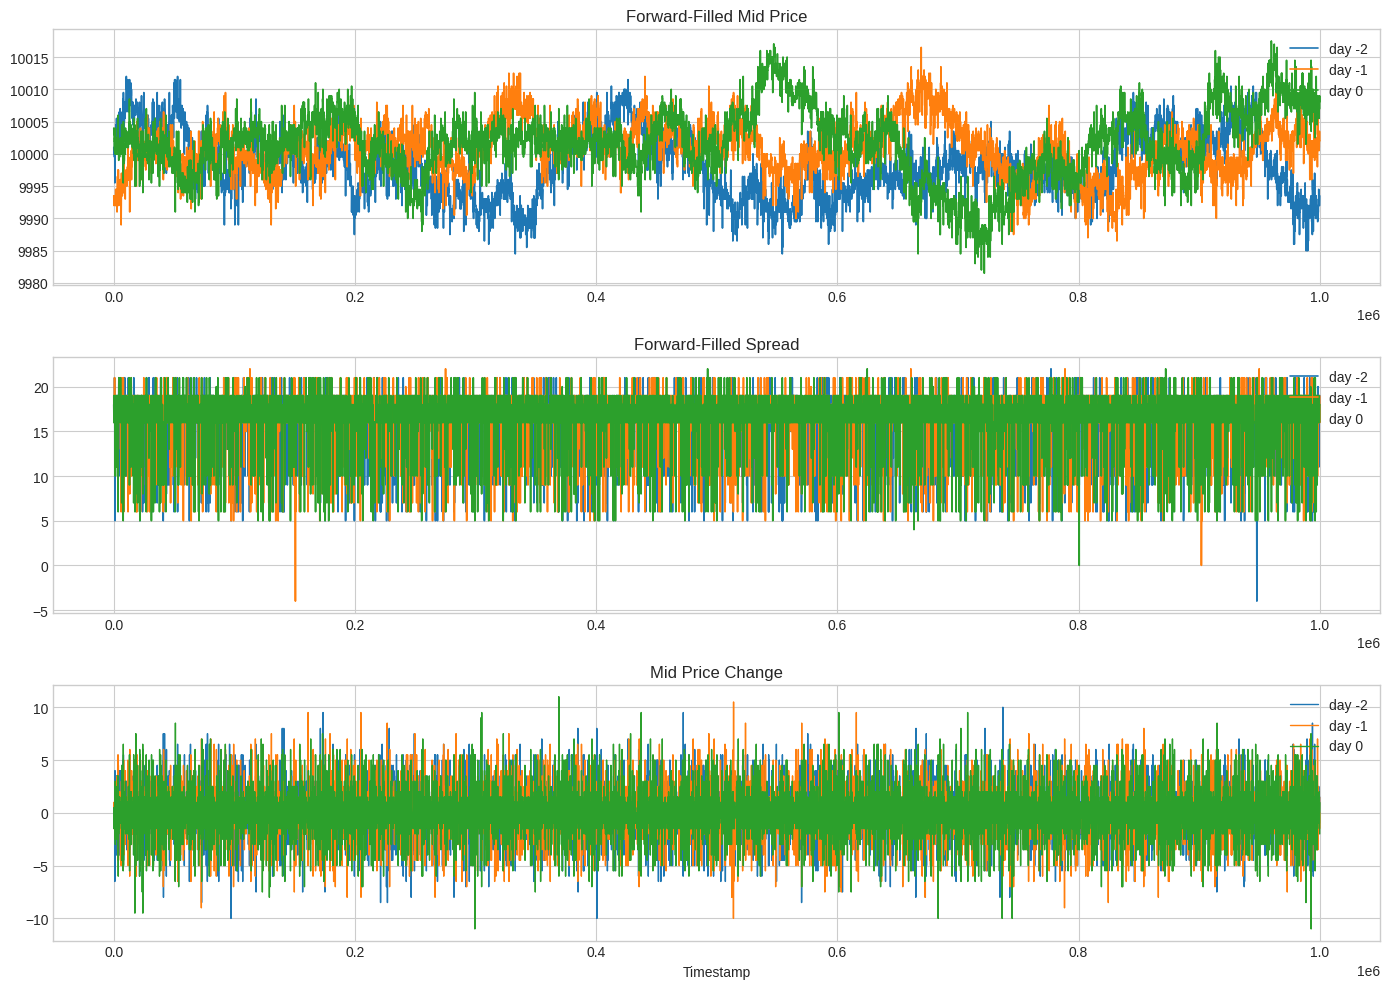

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for day, day_df in ash.groupby('day'):
    axes[0].plot(day_df['timestamp'], day_df['mid_ffill'], label=f'day {day}', linewidth=1.2)
    axes[1].plot(day_df['timestamp'], day_df['spread_ffill'], label=f'day {day}', linewidth=1.2)
    axes[2].plot(day_df['timestamp'], day_df['mid_change'].fillna(0), label=f'day {day}', linewidth=1.0)

axes[0].set_title('Forward-Filled Mid Price')
axes[1].set_title('Forward-Filled Spread')
axes[2].set_title('Mid Price Change')
axes[2].set_xlabel('Timestamp')

for ax in axes:
    ax.legend(loc='upper right')

plt.tight_layout()


## 2. Rolling regime signals

A mixed strategy should not react to volatility alone. Mean-reversion market taking only makes sense when volatility is high **and** short-horizon reversion is still present.

We build three rolling features:
- `vol_signal`: rolling standard deviation of mid-price changes,
- `reversion_signal`: negative rolling lag-1 autocorrelation of mid-price changes,
- `trend_signal`: absolute rolling mean of mid-price changes.

Interpretation:
- high `vol_signal` + high `reversion_signal` -> volatile but mean-reverting,
- high `vol_signal` + high `trend_signal` -> volatile and directional,
- otherwise -> stable.


In [6]:
WINDOW = 200

def rolling_lag1_autocorr(series: pd.Series, window: int) -> pd.Series:
    values = series.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    for idx in range(window - 1, len(values)):
        sample = values[idx - window + 1:idx + 1]
        sample = sample[~np.isnan(sample)]
        if len(sample) < 5:
            continue
        out[idx] = pd.Series(sample).autocorr(lag=1)
    return pd.Series(out, index=series.index)

enriched = []
for day, day_df in ash.groupby('day'):
    day_df = day_df.copy()
    day_df['vol_signal'] = day_df['mid_change'].rolling(WINDOW).std()
    day_df['trend_signal'] = day_df['mid_change'].rolling(WINDOW).mean().abs()
    day_df['lag1_autocorr_roll'] = rolling_lag1_autocorr(day_df['mid_change'], WINDOW)
    day_df['reversion_signal'] = -day_df['lag1_autocorr_roll']
    enriched.append(day_df)

ash_regime = pd.concat(enriched, ignore_index=True)

# Normalize by day so thresholding is more interpretable.
for col in ['vol_signal', 'trend_signal', 'reversion_signal']:
    day_mean = ash_regime.groupby('day')[col].transform('mean')
    day_std = ash_regime.groupby('day')[col].transform('std').replace(0, np.nan)
    ash_regime[f'{col}_z'] = (ash_regime[col] - day_mean) / day_std

ash_regime[['day', 'timestamp', 'vol_signal', 'reversion_signal', 'trend_signal']].tail()


,day,timestamp,vol_signal,reversion_signal,trend_signal
29995,0,999500,2.397,0.489,0.000
29996,0,999600,2.398,0.490,0.005
29997,0,999700,2.397,0.491,0.000
29998,0,999800,2.397,0.490,0.010
29999,0,999900,2.397,0.490,0.010


In [7]:
def classify_regime(row: pd.Series) -> str:
    if pd.isna(row['vol_signal_z']) or pd.isna(row['reversion_signal_z']) or pd.isna(row['trend_signal_z']):
        return 'warmup'
    if row['vol_signal_z'] < 0.5:
        return 'stable'
    if row['reversion_signal_z'] >= 0.0 and row['trend_signal_z'] < 0.75:
        return 'volatile_mean_reverting'
    return 'volatile_trending'

ash_regime['regime'] = ash_regime.apply(classify_regime, axis=1)

regime_counts = (
    ash_regime.groupby(['day', 'regime'])
    .size()
    .unstack(fill_value=0)
)
regime_counts


regime,stable,volatile_mean_reverting,volatile_trending,warmup
day,,,,
-2,6689,1515,1596,200
-1,6816,1732,1252,200
0,6983,1785,1032,200


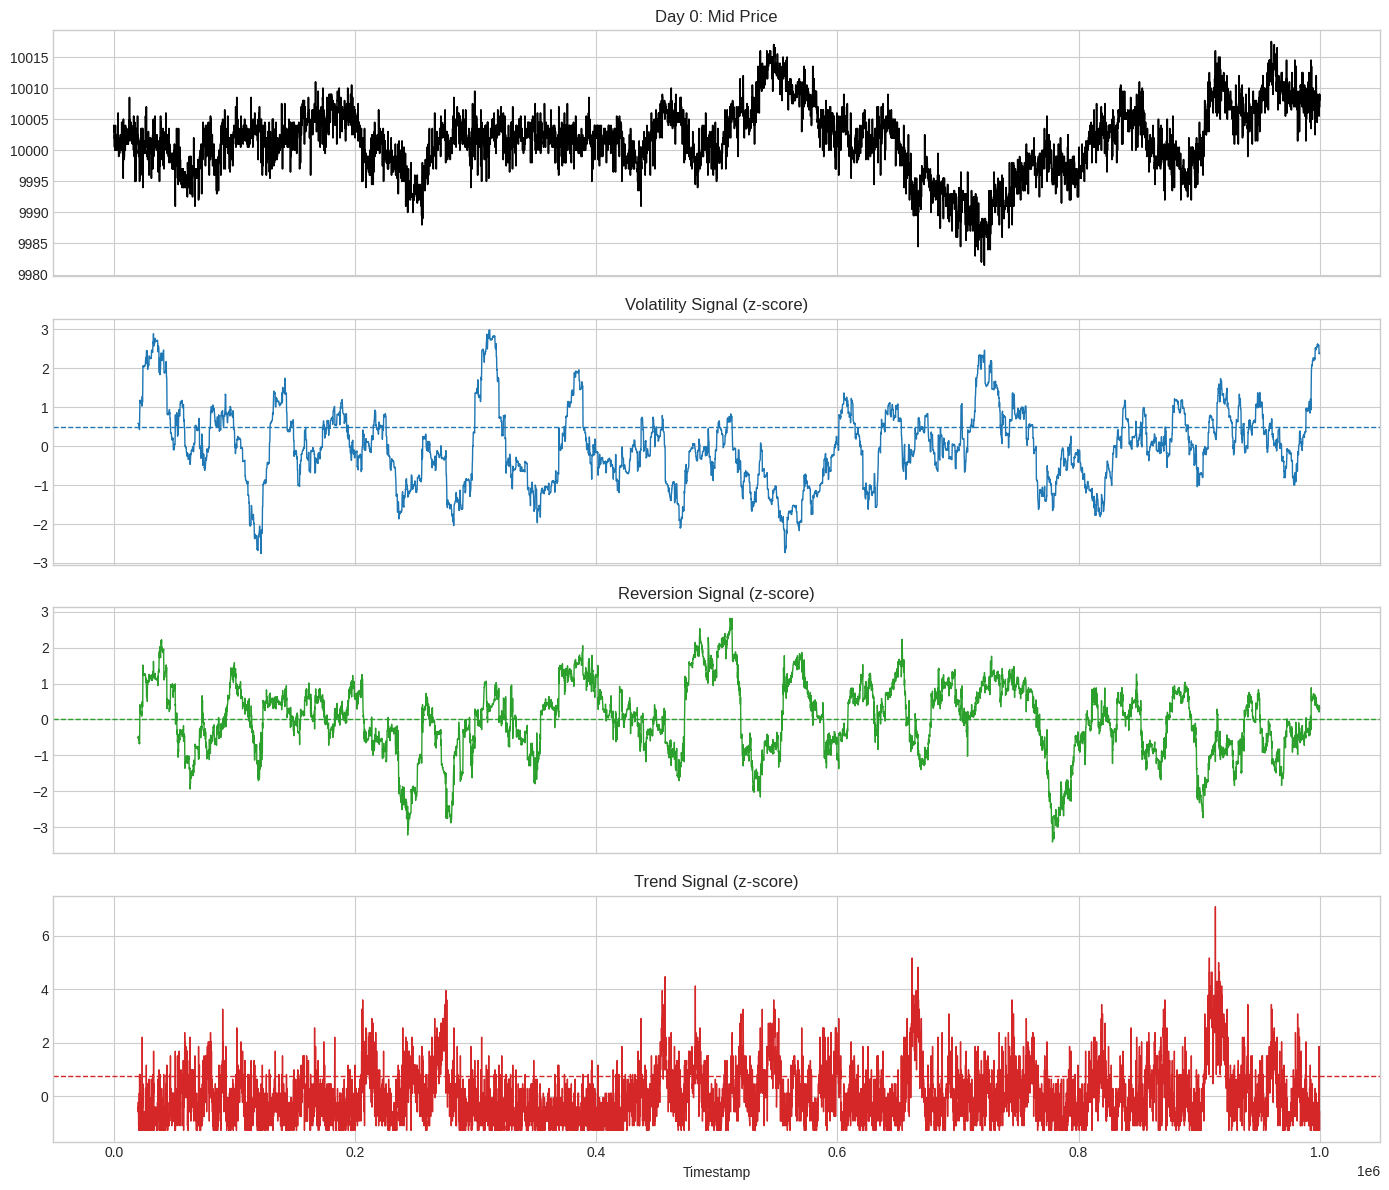

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

sample_day = 0
plot_df = ash_regime.loc[ash_regime['day'] == sample_day].copy()

axes[0].plot(plot_df['timestamp'], plot_df['mid_ffill'], color='black', linewidth=1.2)
axes[0].set_title(f'Day {sample_day}: Mid Price')

axes[1].plot(plot_df['timestamp'], plot_df['vol_signal_z'], color='tab:blue', linewidth=1.0)
axes[1].axhline(0.5, color='tab:blue', linestyle='--', linewidth=1)
axes[1].set_title('Volatility Signal (z-score)')

axes[2].plot(plot_df['timestamp'], plot_df['reversion_signal_z'], color='tab:green', linewidth=1.0)
axes[2].axhline(0.0, color='tab:green', linestyle='--', linewidth=1)
axes[2].set_title('Reversion Signal (z-score)')

axes[3].plot(plot_df['timestamp'], plot_df['trend_signal_z'], color='tab:red', linewidth=1.0)
axes[3].axhline(0.75, color='tab:red', linestyle='--', linewidth=1)
axes[3].set_title('Trend Signal (z-score)')
axes[3].set_xlabel('Timestamp')

plt.tight_layout()


## 3. Convert regime into MM/MT weights

Instead of committing to a single fixed mixture, use the regime to allocate risk budget.

Suggested starting weights:
- `stable`: almost all passive market making,
- `volatile_mean_reverting`: reduce passive size and add active mean-reversion taking,
- `volatile_trending`: cut active taking sharply and leave more headroom.


In [9]:
WEIGHTS = {
    'stable': {'passive_weight': 0.85, 'active_weight': 0.00, 'reserve_weight': 0.15},
    'volatile_mean_reverting': {'passive_weight': 0.55, 'active_weight': 0.25, 'reserve_weight': 0.20},
    'volatile_trending': {'passive_weight': 0.30, 'active_weight': 0.05, 'reserve_weight': 0.65},
    'warmup': {'passive_weight': 0.50, 'active_weight': 0.00, 'reserve_weight': 0.50},
}

weights_df = pd.DataFrame.from_dict(WEIGHTS, orient='index')
weights_df


,passive_weight,active_weight,reserve_weight
stable,0.850,0.000,0.150
volatile_mean_reverting,0.550,0.250,0.200
volatile_trending,0.300,0.050,0.650
warmup,0.500,0.000,0.500


In [10]:
LIMIT = 80

ash_regime['passive_weight'] = ash_regime['regime'].map(lambda regime: WEIGHTS[regime]['passive_weight'])
ash_regime['active_weight'] = ash_regime['regime'].map(lambda regime: WEIGHTS[regime]['active_weight'])
ash_regime['reserve_weight'] = ash_regime['regime'].map(lambda regime: WEIGHTS[regime]['reserve_weight'])

ash_regime['passive_budget'] = LIMIT * ash_regime['passive_weight']
ash_regime['active_budget'] = LIMIT * ash_regime['active_weight']
ash_regime['reserve_budget'] = LIMIT * ash_regime['reserve_weight']

budget_summary = ash_regime.groupby(['day', 'regime']).agg(
    samples=('timestamp', 'size'),
    passive_budget=('passive_budget', 'mean'),
    active_budget=('active_budget', 'mean'),
    reserve_budget=('reserve_budget', 'mean'),
)
budget_summary


samples  passive_budget  active_budget  \
day regime                                                            
-2  stable                      6689          68.000          0.000   
    volatile_mean_reverting     1515          44.000         20.000   
    volatile_trending           1596          24.000          4.000   
    warmup                       200          40.000          0.000   
-1  stable                      6816          68.000          0.000   
    volatile_mean_reverting     1732          44.000         20.000   
    volatile_trending           1252          24.000          4.000   
    warmup                       200          40.000          0.000   
 0  stable                      6983          68.000          0.000   
    volatile_mean_reverting     1785          44.000         20.000   
    volatile_trending           1032          24.000          4.000   
    warmup                       200          40.000          0.000   

                             reserve_budget  
day regime                                   
-2  stable                           12.000  
    volatile_mean_reverting          16.000  
    volatile_trending                52.000  
    warmup                           40.000  
-1  stable                           12.000  
    volatile_mean_reverting          16.000  
    volatile_trending                52.000  
    warmup                           40.000  
 0  stable                           12.000  
    volatile_mean_reverting          16.000  
    volatile_trending                52.000  
    warmup                           40.000

## 4. Trading interpretation

Use the regime output as a position-sizing overlay on top of your existing trader logic.

Implementation guidance for `latest_trader.py`:
- keep passive inside-spread quoting in stable periods,
- switch to smaller passive quote sizes when volatility rises,
- only enable mean-reversion taking when volatility is high and reversion remains strong,
- disable or heavily reduce mean-reversion taking when the market becomes directional,
- replace the fixed mean-reversion anchor of `10000` with a rolling fair value from recent mids.

Practical first version:
- quote with `passive_budget` on the passive side,
- allow aggressive reversion trades only up to `active_budget`,
- keep `reserve_budget` unused so you can absorb inventory shocks.
